<a href="https://colab.research.google.com/github/AnastasiaKovalenko232/iad-practices/blob/main/practice-6/6_3_Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dimensionality Reduction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Імпортуємо датасет та інструменти обробки
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

## Get the Data

In [ ]:
wine_data = load_wine()

In [ ]:
wine_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [ ]:
wine_data['feature_names']

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [ ]:
X = wine_data['data']

## Principal component analysis

In [ ]:
from sklearn.decomposition import PCA
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_std)

In [ ]:
exp_var_pca = pca.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

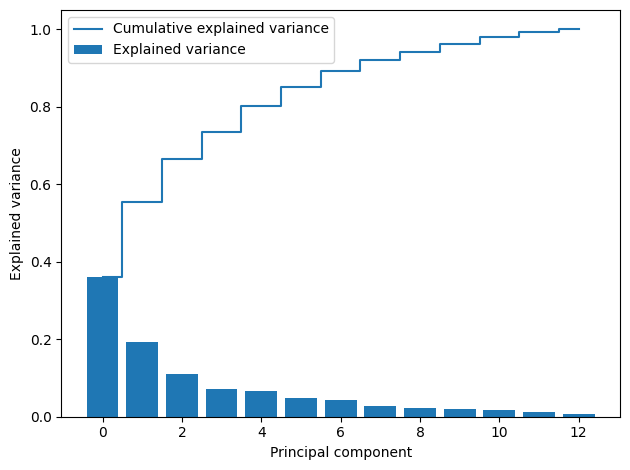

In [ ]:
plt.bar(range(0,len(exp_var_pca)), exp_var_pca, align='center', label='Explained variance')
plt.step(range(0,len(cum_sum_eigenvalues)), cum_sum_eigenvalues, where='mid',label='Cumulative explained variance')
plt.ylabel('Explained variance')
plt.xlabel('Principal component')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## Digits

In [ ]:
digits = load_digits()

X = digits.data
y = digits.target
print(digits.data.shape)

(1797, 64)


<Figure size 640x480 with 0 Axes>

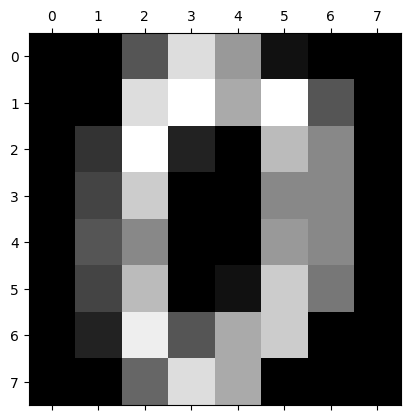

In [ ]:
plt.gray()
plt.matshow(digits.images[0])
plt.show()

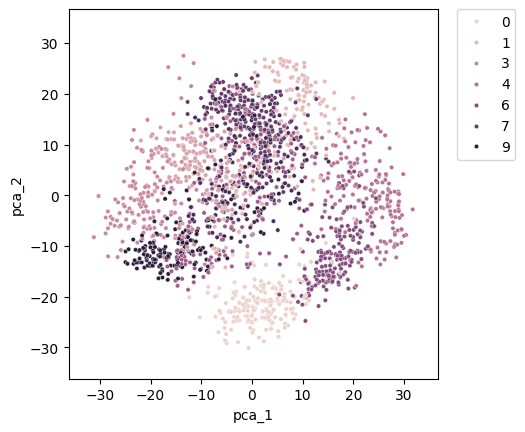

In [ ]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

pca_result_df = pd.DataFrame({'pca_1': pca_result[:,0], 'pca_2': pca_result[:,1], 'label': y})

fig, ax = plt.subplots(1)
sns.scatterplot(x='pca_1', y='pca_2', hue='label', data=pca_result_df, ax=ax,s=10)
lim = (pca_result.min()-5, pca_result.max()+5)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

# tSNE

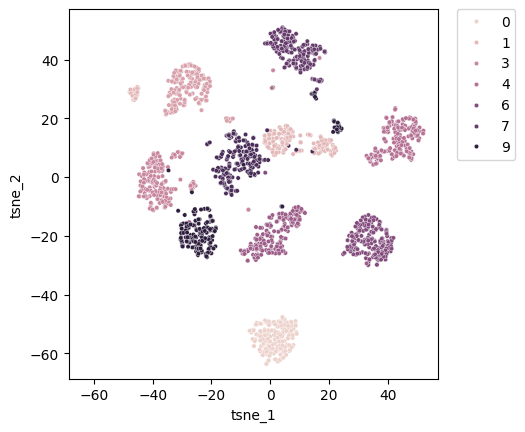

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)
tsne_result = tsne.fit_transform(X)

tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:,0], 'tsne_2': tsne_result[:,1], 'label': y})

fig, ax = plt.subplots(1)
sns.scatterplot(x='tsne_1', y='tsne_2', hue='label', data=tsne_result_df, ax=ax,s=10)
lim = (tsne_result.min()-5, tsne_result.max()+5)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


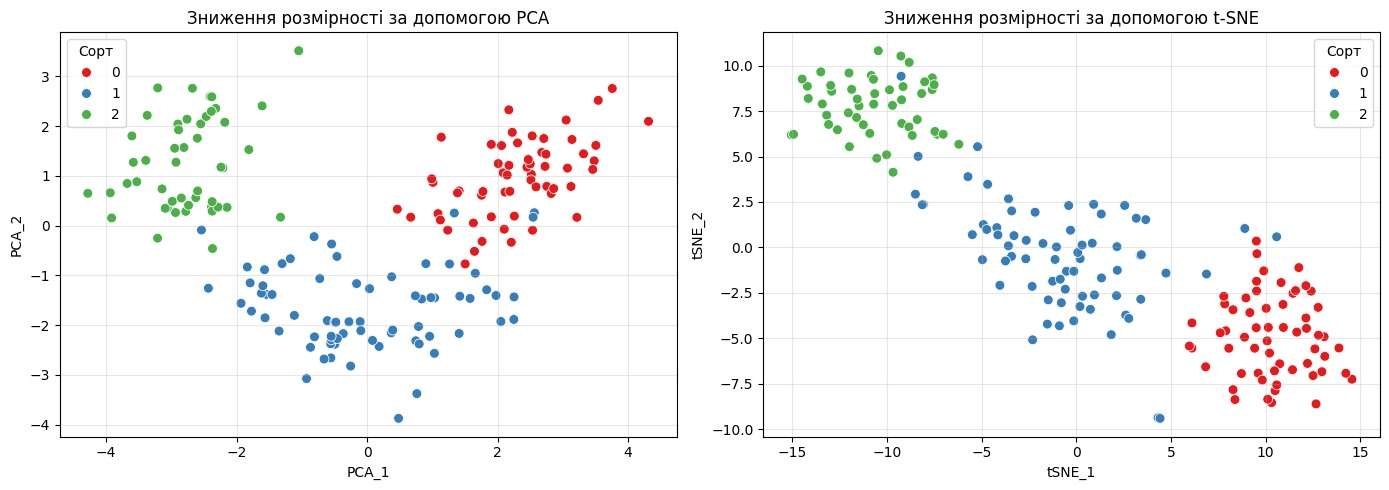

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Завантаження багатовимірного датасету Wine (13 ознак)
wine = load_wine()
X = wine.data
y = wine.target

# Обов'язкове масштабування перед зниженням розмірності!
X_scaled = StandardScaler().fit_transform(X)

# 2. Метод 1: Лінійне зниження розмірності через PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame({'PCA_1': pca_result[:, 0], 'PCA_2': pca_result[:, 1], 'Сорт': y})

# 3. Метод 2: Нелінійне зниження розмірності через t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(X_scaled)
df_tsne = pd.DataFrame({'tSNE_1': tsne_result[:, 0], 'tSNE_2': tsne_result[:, 1], 'Сорт': y})

# 4. Побудова графіків порівняння методів
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='PCA_1', y='PCA_2', hue='Сорт', palette='Set1', data=df_pca, ax=ax1, s=50)
ax1.set_title('Зниження розмірності за допомогою PCA')
ax1.grid(True, alpha=0.3)

sns.scatterplot(x='tSNE_1', y='tSNE_2', hue='Сорт', palette='Set1', data=df_tsne, ax=ax2, s=50)
ax2.set_title('Зниження розмірності за допомогою t-SNE')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()